# Pytorch Worklow


This notebook will guide you through the classical workflow of modelling using pytorch.

**What does our workflow look like?**

A typical workflow is as follows:

1. Load and process data
2. Build model(s)
3. Train the model(s)
4. Make predictions from model(s) (this is also called **inference**)
5. Save and load the model


Let's dive into each process step by step

## Loading and Processing Data

This is the first step of any modelling task.

For most machine learning use-cases, we have a set of data and we aim to learn some relationship between the data.

Why process data? Because data can be dirty (empty/incosistent values, features that are more noise and signal) and our model is as good as our dataset.

### Create dummy data

We will create data that can be modelled using a straight line

Machine Learning is broadly divided into three parts : supervised (labelled data), unsupervised (unlabelled data), and RL.

Supervised Learning further has two possible cases : Use data to predict a continuous target (regression), or a discrete target (classification)

Data that can be modelled using a straight line is a regression task. Specificically, It is called Linear Regression.

Let there be data

In [2]:
# To model data using a straight line, we use y = wx + b where w = weight and b = bias
import torch
weight = 0.7
bias = 0.3

start =0
end = 1
step = 0.02

X = torch.arange(start,end,step)
y = X*weight + bias

X,y

(tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
         0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
         0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
         0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
         0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800,
         0.9000, 0.9200, 0.9400, 0.9600, 0.9800]),
 tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560, 0.3700, 0.3840, 0.3980, 0.4120,
         0.4260, 0.4400, 0.4540, 0.4680, 0.4820, 0.4960, 0.5100, 0.5240, 0.5380,
         0.5520, 0.5660, 0.5800, 0.5940, 0.6080, 0.6220, 0.6360, 0.6500, 0.6640,
         0.6780, 0.6920, 0.7060, 0.7200, 0.7340, 0.7480, 0.7620, 0.7760, 0.7900,
         0.8040, 0.8180, 0.8320, 0.8460, 0.8600, 0.8740, 0.8880, 0.9020, 0.9160,
         0.9300, 0.9440, 0.9580, 0.9720, 0.9860]))

### Splitting data into train, test and validation sets.
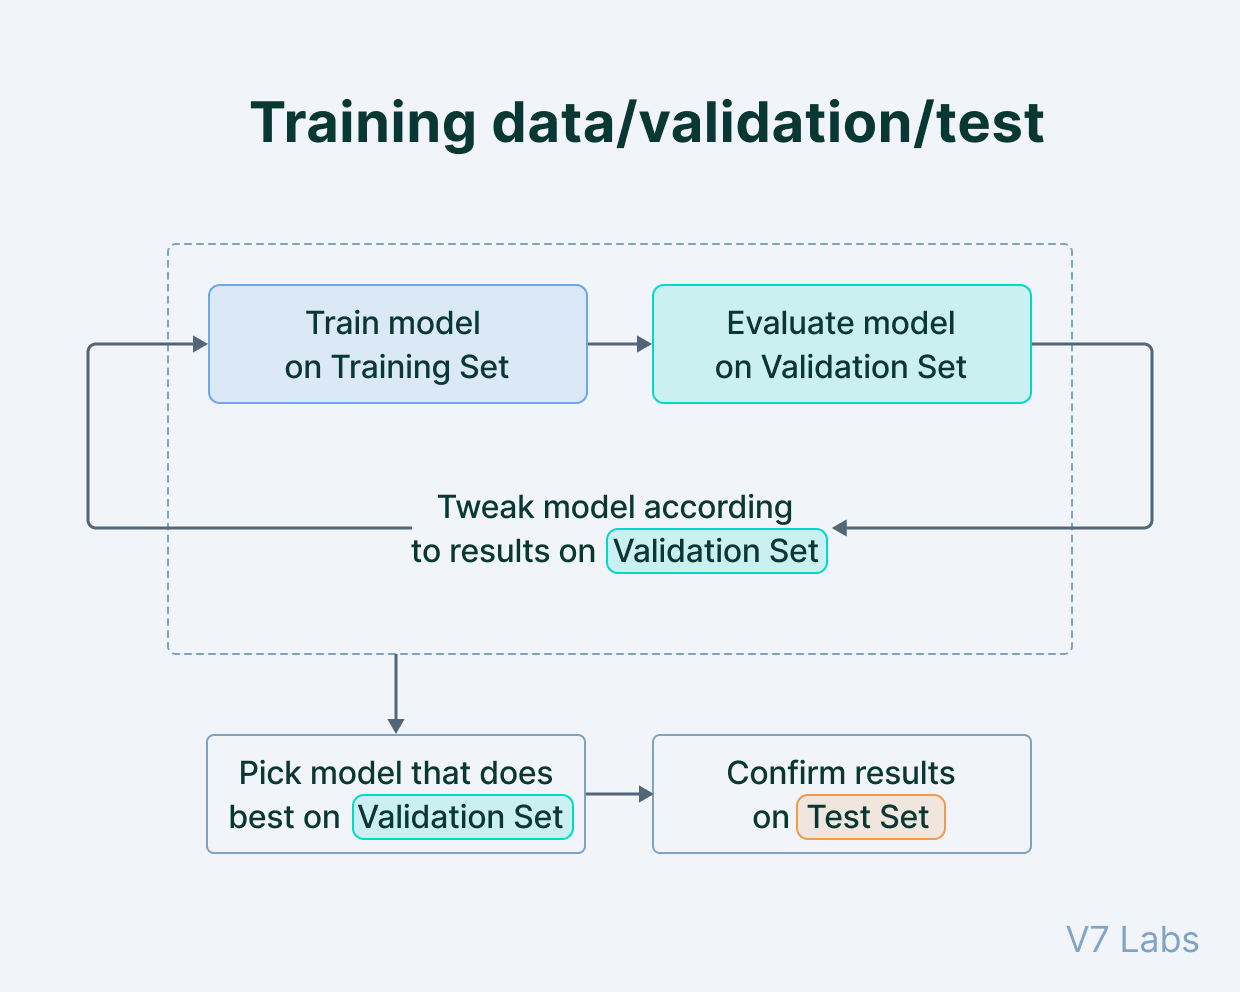

In [3]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visualizing data

Why? To develop an intuition of the underlying structure of data.

The most commonly used library is matplotlib.

In [4]:
import matplotlib.pyplot as plt

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

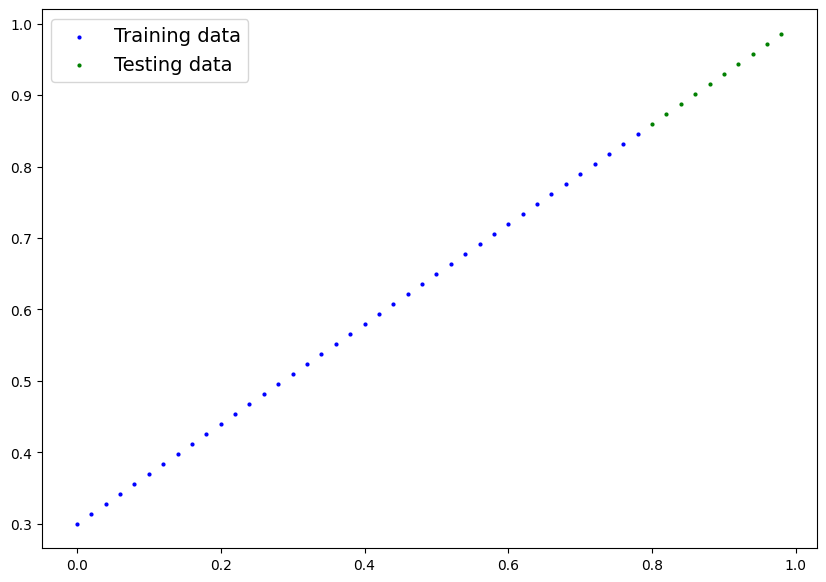

In [5]:
plot_predictions()

### Readings:

Additional Readings.

These use a library called scikit-learn.

- **Imputing Null Data**:
  - [Handling Missing Data in Python](https://www.datacamp.com/community/tutorials/dealing-with-missing-data-python)
  - [Missing Data Imputation](https://scikit-learn.org/stable/modules/impute.html)
- **Standardizing Data**:
  - [Data Standardization with Scikit-learn](https://www.datacamp.com/community/tutorials/normalization-and-standardization-in-python)
  - [Feature Scaling](https://towardsdatascience.com/feature-scaling-standardization-vs-normalization-c340579e274b)

## Building the model

Now that we've learnt the two key steps of loading and processing our data, and hopefully you read the readings on imputing and standardization, it's time to build our model.

Models in pytorch are built using Python classes. They leverage Object Oriented Programming. A module, in this context, refers to a reusable component that encapsulates operations and variables, similar to a class or a function, but specifically designed for neural network layers and models.

Here are some of the key PyTorch components and what they do:

| PyTorch module | What does it do? |
|---|---|
| `torch.nn` | Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way). |
| `torch.nn.Parameter` | Stores tensors that can be used with `nn.Module`. If `requires_grad=True` gradients (used for updating model parameters via gradient descent) are calculated automatically, this is often referred to as "autograd". |
| `torch.nn.Module` | The base class for all neural network modules, all the building blocks for neural networks are subclasses. If you're building a neural network in PyTorch, your models should subclass `nn.Module`. Requires a `forward()` method be implemented. |
| `torch.optim` | Contains various optimization algorithms (these tell the model parameters stored in `nn.Parameter` how to best change to improve gradient descent and in turn reduce the loss). |
| `def forward()` | All `nn.Module` subclasses require a `forward()` method, this defines the computation that will take place on the data passed to the particular `nn.Module` (e.g. the linear regression formula above). |

In [6]:
# create a linear regression model
import torch.nn as nn

class LinearRegression(nn.Module):
  def __init__(self): #constructor
    super(LinearRegression, self).__init__()
    self.weights = nn.Parameter(torch.randn(1,dtype = float, requires_grad=True)) #let's start with random numbers, requires_grad = True stores computation for gradient descent
    self.bias = nn.Parameter(torch.randn(1,dtype = float, requires_grad=True))

  def forward(self, x : torch.Tensor): # define the forward pass for this model
    return self.weights * x + self.bias # y = wx + b



## Describing our model

Let's explore our model

In [7]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegression()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

#Get the models contents
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367], dtype=torch.float64)),
             ('bias', tensor([0.1288], dtype=torch.float64))])

## Training a model

The next step is to train our model. To train our model, we need two major parts.

1. Loss function : Measures the difference in the predicted output and the true value of the parameter. For this problem, a sufficient loss function is the Mean Absolute error.

2. Optimizer : Algorithm to find the minimum of the loss function (usually gradient descent with a few buffs, see [Adam](https://arxiv.org/abs/1412.6980).) For now we shall use Stochastic Gradient Descent.

In [9]:
# define loss function

loss_fn = torch.nn.L1Loss()

#define the optimizer

optimizer = torch.optim.SGD(model_0.parameters(), lr=0.01) # learning rate (lr) is a hyperparam that controls the step size of gradient descent

### The training loop

Here is what the training loop looks like.

On training data,

1. Forward pass : Pass the input through the model to get a predicted value.

2. Loss : Calculate the loss between the predicted value and the absolute value

3. Init Gradients : Set optimizer gradients to 0 and begin.

4. Backprop : Chain rule to simplify gradient calculations for model with many interlinked parameters

5. Update : Use the optimizer to apply gradient descent (or ascent) to the parameters.


### The testing loop

It is important to test how well our model is learning.

Here is what the testing loop looks like:

On testing data (unseen before):

1. Forward Pass : Pass unseen data to the model and compute an output

2. Loss : Calculate the loss function between the predicted and true parameters

3. Evaluation Metrics : Calculate other evaluation metrics



Let us train for 100 epochs, and test every 100 epochs.

In [13]:
torch.manual_seed(42)

train_loss_val = list()
test_loss_val = list()
epochs = 100
epoch_count = []
### Training
for epoch in range(epochs):
  # Train
  model_0.train()
  #Loss
  y_pred = model_0(X_train)
  loss = loss_fn(y_pred,y_train)
  # init gradient
  optimizer.zero_grad()
  #backprop
  loss.backward()
  #update
  optimizer.step()

### Testing

  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test)
    test_loss = loss_fn(test_pred,y_test)

  # Print out what's happening
    if epoch % 10 == 0:
          epoch_count.append(epoch)
          train_loss_val.append(loss.detach().numpy())
          test_loss_val.append(test_loss.detach().numpy())
          print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")




Epoch: 0 | MAE Train Loss: 0.27831835702846164 | MAE Test Loss: 0.4406521842603248 
Epoch: 10 | MAE Train Loss: 0.16310835766481552 | MAE Test Loss: 0.3059421846144879 
Epoch: 20 | MAE Train Loss: 0.07160004032174225 | MAE Test Loss: 0.18908658496699787 
Epoch: 30 | MAE Train Loss: 0.04982281940293563 | MAE Test Loss: 0.132715885275513 
Epoch: 40 | MAE Train Loss: 0.044237931071767114 | MAE Test Loss: 0.10826938551340264 
Epoch: 50 | MAE Train Loss: 0.0406316065316361 | MAE Test Loss: 0.09589338577358428 
Epoch: 60 | MAE Train Loss: 0.03716408489002549 | MAE Test Loss: 0.08624718603522029 
Epoch: 70 | MAE Train Loss: 0.03372840687504599 | MAE Test Loss: 0.07797478628919116 
Epoch: 80 | MAE Train Loss: 0.030290595184838898 | MAE Test Loss: 0.07038928653932944 
Epoch: 90 | MAE Train Loss: 0.02686215533321823 | MAE Test Loss: 0.062116886793300276 


Plot the loss to understand overfitting vs underfitting

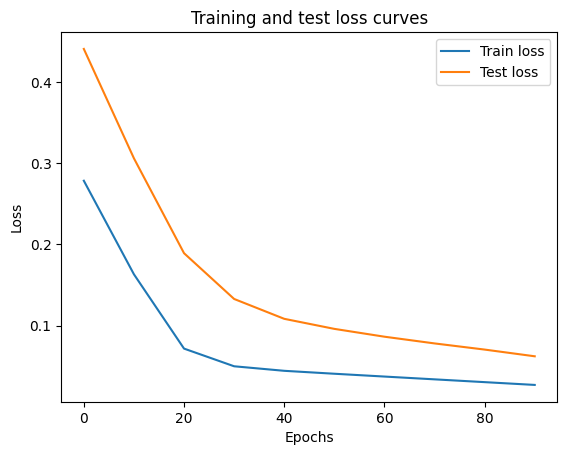

In [15]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_val, label="Train loss")
plt.plot(epoch_count, test_loss_val, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Inspect the model after training (the weights and biases should have evolved to be better)

In [16]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.5834], dtype=torch.float64), 'bias': tensor([0.3488], dtype=torch.float64)})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


## Make Predictions from the model (inference)

We already kind of covered this but inference is the process of making predictions from the model using the learned parameters.

The important thing here is that the parameters once learned are frozen during inference, and no training occurs, so this is simply a forward pass and computing the loss and other metrics, which is why it can be faster than training.

Finally, when performing inference, your data and model should be on the same device (both on CPU/GPU/MPS)

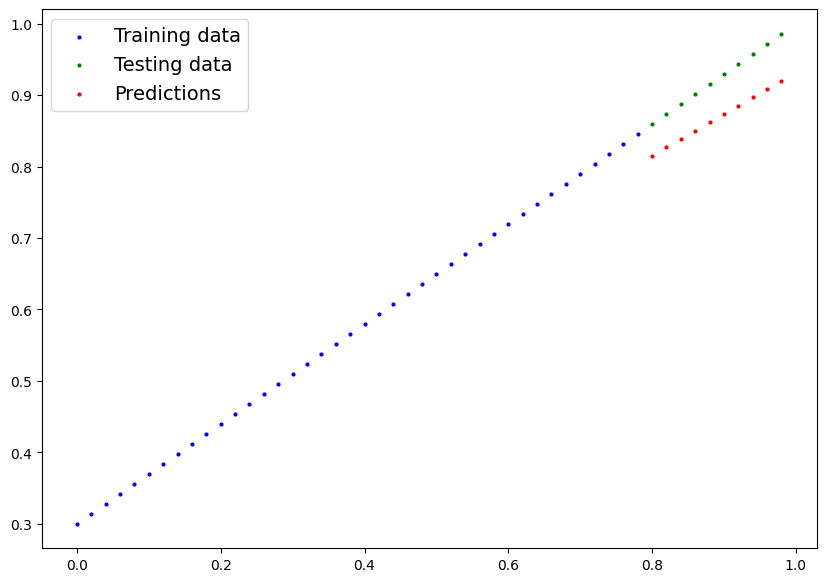

In [19]:
# set model in evaluation mode

model_0.eval()

# make predictions

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

plot_predictions(predictions=y_preds)

## Exporting and Importing Pytorch Models

Once we built the model and trained it, it may be useful to export it for deployement purposes.

In [20]:
# Store using model.dict()

from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [21]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

-rw-r--r-- 1 root root 2117 Mar 19 04:00 models/01_pytorch_workflow_model_0.pth


In [22]:
#Loading the state_dict
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegression()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>